In [1]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
import torch

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_field_run,
    postprocess_field_run_overview,
    display_field_run_overview,
    postprocess_build_active_field_diagnostics,
    field_summary_table,
    print_field_diagnostics,
    plot_field_frame_component_trends,
    plot_field_frame_component_heatmaps,
    plot_field_diversity,
    display_field_sample_error_summary,
    display_field_node_error_summary,
    field_sample_viewer,
    plot_field_sample_frame_evolution,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
%load_ext autoreload
%autoreload 2

# ML Field Post-Processing

## 1. Find Recent Runs

In [3]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")

if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=25, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")

## 2. User Configuration

Set the run identity here. `run_type` controls whether the path points to a standard run, a model-specific HPO run, or one model inside a cross-model HPO run.

In [4]:
mechMode = "UT"
model = "Transformer"
run_name = "TR-Field-UT-1"
VIEW_MODE = None
run_type = "standard"  # "standard", "model_hpo", or "cross_model_hpo"
RUN_PATH_OVERRIDE = None

if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / model / "HPO" / run_name
elif run_type == "cross_model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'cross_model_hpo'.")

DATA_PATH_OVERRIDE = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = True
LOAD_MODEL = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = None


## 3. Load Run Artifacts

In [5]:
artifacts, loaded, DAT, MOD = postprocess_load_field_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


Loaded DATA from: Z:\p2\UT\Transformer\TR-Field-UT-1\model_data.json
DATA output_kind: field
Loaded MODEL from: Z:\p2\UT\Transformer\TR-Field-UT-1\model.json


,artifact,path_or_value
0,input_path,Z:\p2\UT\Transformer\TR-Field-UT-1
1,run_dir,Z:\p2\UT\Transformer\TR-Field-UT-1
2,model_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model.json
3,model_mdl,Z:\p2\UT\Transformer\TR-Field-UT-1\model.mdl
4,data_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model_data....
5,results_dir,Z:\p2\UT\Transformer\TR-Field-UT-1\results
6,metrics_json,Z:\p2\UT\Transformer\TR-Field-UT-1\results\met...
7,predictions_npz,Z:\p2\UT\Transformer\TR-Field-UT-1\results\pre...
8,loss_history_csv,NaN
9,diagnostics_summary_json,Z:\p2\UT\Transformer\TR-Field-UT-1\results\dia...


## 4. Run Setup And Available Outputs

In [6]:
overview = postprocess_field_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_field_evals = overview["available_field_evals"]
ACTIVE_SPLIT = overview["active_split"]

display_field_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


,item,value
0,run,TR-Field-UT-1
1,run_type,standard
2,mechMode,UT
3,VIEW_MODE,UT
4,model,Transformer
5,output_kind,field
6,device,cpu
7,evaluation_split,test
8,is_hpo,False
9,model_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model.json


### Saved Metrics For Active View

,metric,value
0,UT_best_epoch,24
1,UT_best_loss,0.013058
2,UT_best_mse,0.013058
3,UT_best_rmse,"[False, 0.11427342798177295]"
4,UT_mae,0.466538
5,UT_mse,0.989384
6,UT_rmse,0.994678
7,UT_best,124
8,UT_worst,188


### Available Field Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,frame_metrics,component_metrics,node_metrics
0,UT,test,True,True,True,True,True,True


No HPO files were found for this run.
mechMode: UT
VIEW_MODE: UT
ACTIVE_SPLIT: test


## 5. Build Active Field Diagnostics

In [7]:
diagnostics, active_key, active_diag = postprocess_build_active_field_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    print_field_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


UT test prediction diagnostics | RMSE: 0.9947 | MAE: 0.4665 | mean-field RMSE: 1.074 | skill vs mean field: 0.0742 | collapse ratio: 0.466 | valid: 1


## 6. Active Diagnostic Summary

In [8]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "collapse_ratio",
    "mean_field_baseline_rmse",
    "skill_vs_mean_field_rmse",
    "valid_fraction",
    "n_samples",
    "n_frames",
    "n_nodes",
    "n_components",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    display(field_summary_table(active_diag, metrics=SUMMARY_METRICS))


,metric,value
0,rmse,0.994678
1,mae,0.466538
2,mse,0.989384
3,bias,-0.025421
4,collapse_ratio,0.466498
5,mean_field_baseline_rmse,1.074383
6,skill_vs_mean_field_rmse,0.074187
7,valid_fraction,0.999944
8,n_samples,889.000000
9,n_frames,20.000000


## 7. Frame And Component Performance

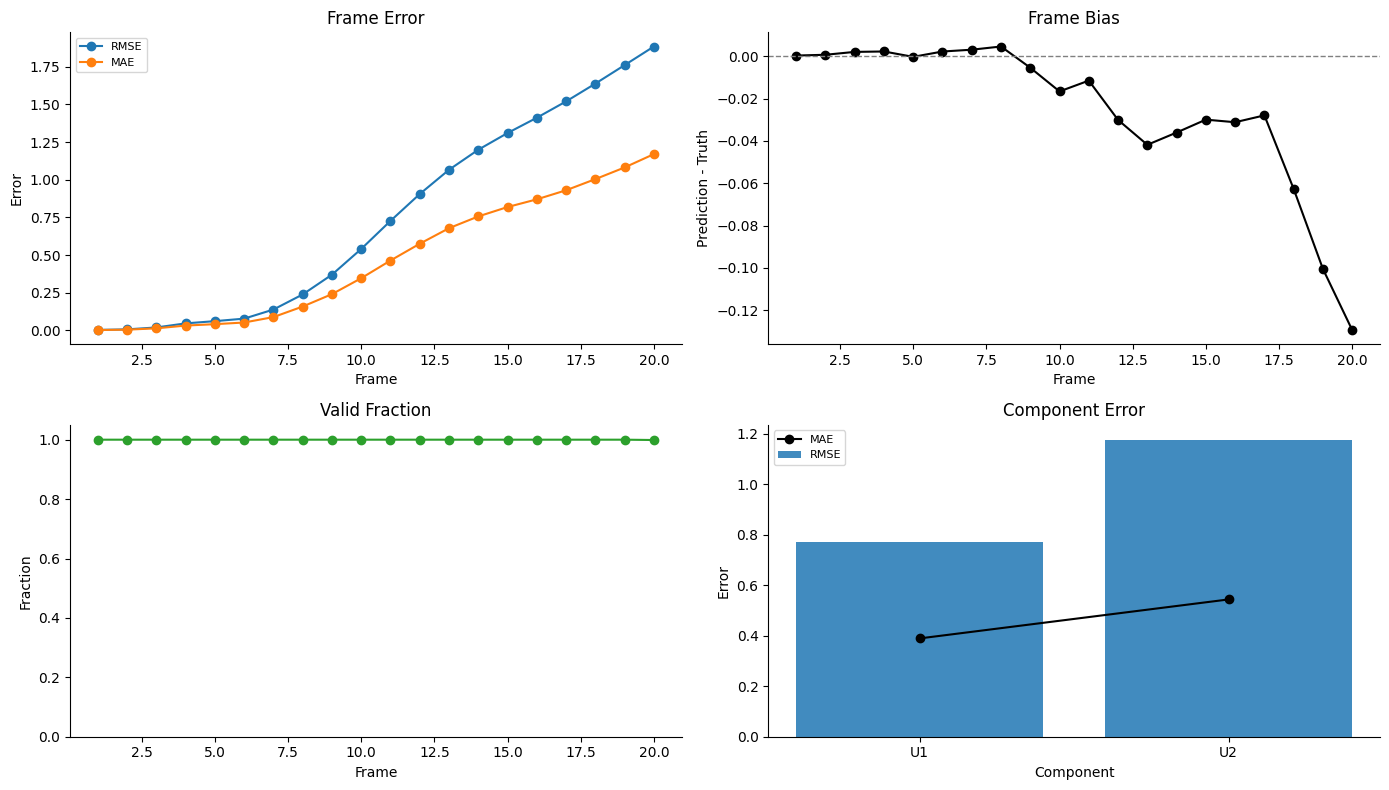

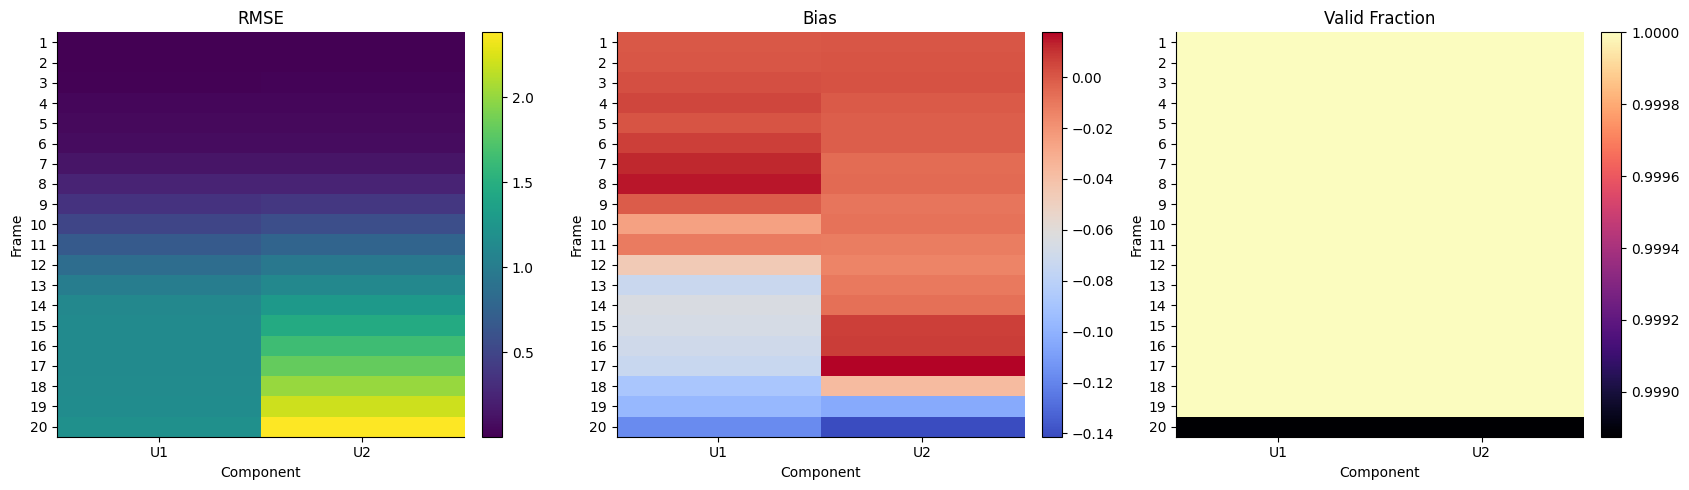

### Component Metrics

,component,mae,mse,rmse,bias,valid_fraction
0,U1,0.389376,0.595084,0.771417,-0.034569,0.999944
1,U2,0.543701,1.383684,1.176301,-0.016272,0.999944


In [9]:
FRAME_TRENDS_FIGSIZE = (14, 8)
HEATMAP_FIGSIZE = (17, 5)
HEATMAP_CMAPS = {"RMSE": "viridis", "Bias": "coolwarm", "Valid Fraction": "magma"}
SHOW_COMPONENT_TABLE = True


if active_diag is None:
    print("No active diagnostics are available.")
else:
    plot_field_frame_component_trends(active_diag, figsize=FRAME_TRENDS_FIGSIZE)
    plot_field_frame_component_heatmaps(active_diag, figsize=HEATMAP_FIGSIZE, cmaps=HEATMAP_CMAPS)

    component_metrics = active_diag.get("component_metrics")
    if SHOW_COMPONENT_TABLE and hasattr(component_metrics, "copy"):
        display(Markdown("### Component Metrics"))
        display(component_metrics)


## 8. Prediction Collapse And Field Diversity

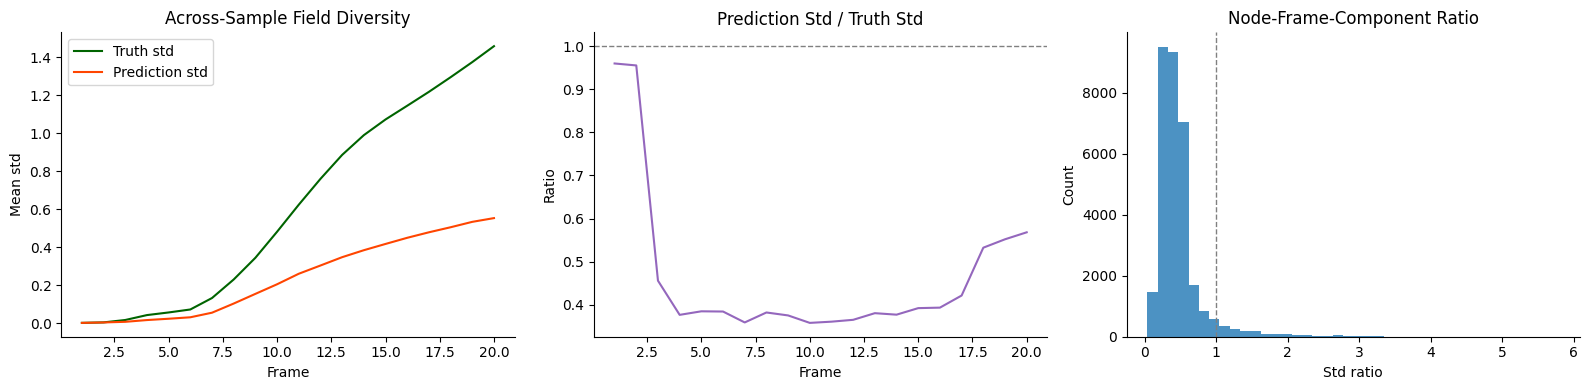

In [10]:
DIVERSITY_FIGSIZE = (16, 4)
DIVERSITY_RATIO_REFERENCE = 1.0
DIVERSITY_BINS = 40


if active_diag is None:
    print("No active diagnostics are available.")
else:
    try:
        plot_field_diversity(
            active_diag,
            figsize=DIVERSITY_FIGSIZE,
            ratio_reference=DIVERSITY_RATIO_REFERENCE,
            bins=DIVERSITY_BINS,
        )
    except ValueError as exc:
        print(exc)


## 9. Sample-Level Error

### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,valid_fraction
124,124,0.144992,0.105882,0.325395,0.031977,1.0
439,439,0.147003,0.123755,0.351788,-0.029317,1.0
543,543,0.168522,0.142175,0.377061,-0.045570,1.0
266,266,0.224071,0.157161,0.396435,-0.055241,1.0
75,75,0.197795,0.186239,0.431554,-0.096576,1.0
79,79,0.760319,2.593667,1.610486,0.034828,1.0
274,274,0.807280,2.704283,1.644470,-0.016764,1.0
885,885,0.749226,2.817799,1.678630,-0.041264,1.0
307,307,0.778348,2.892177,1.700640,-0.021492,1.0
188,188,0.807762,3.082390,1.755674,-0.196135,1.0


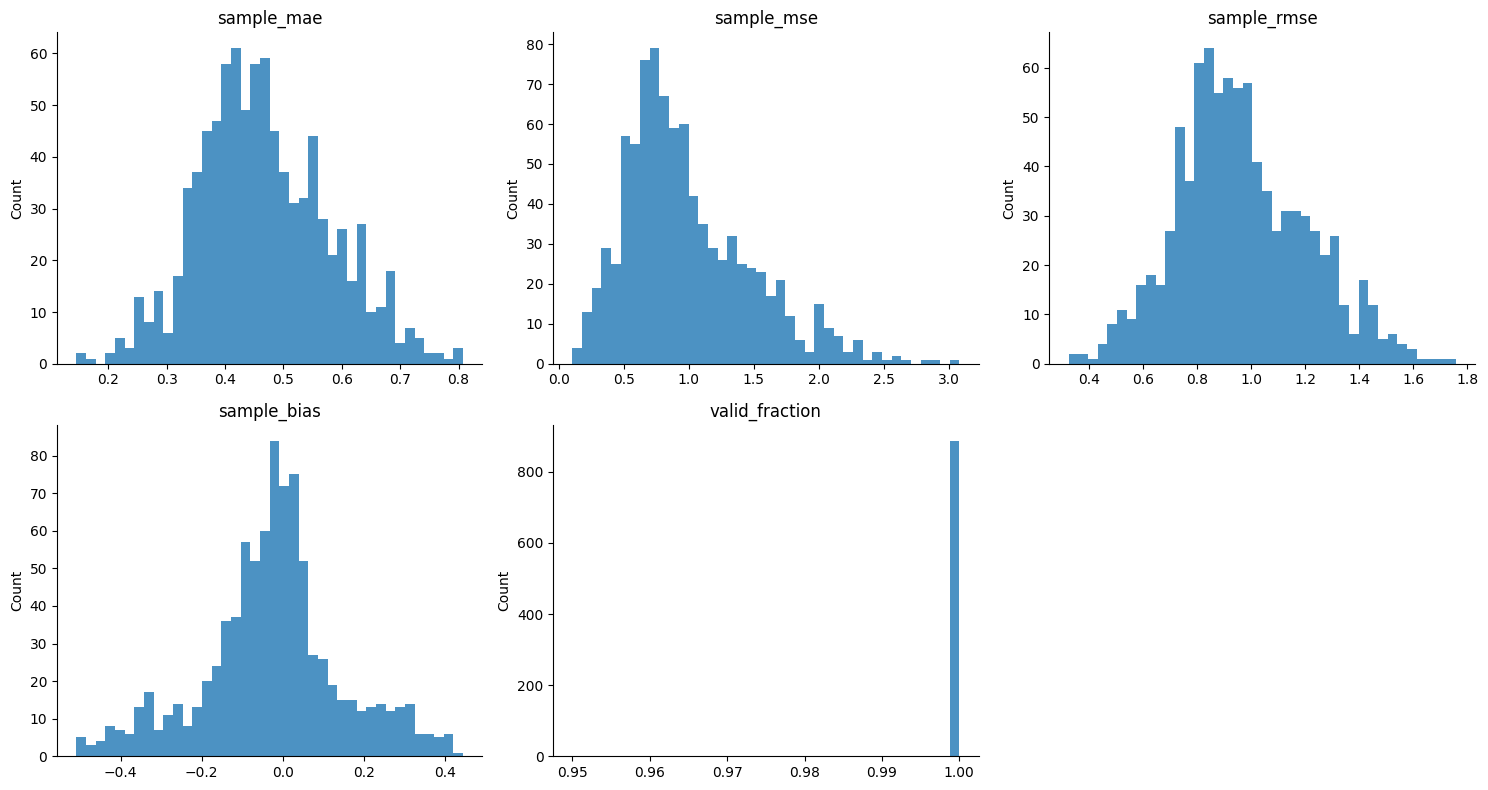

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,889.0,0.466546,0.112216,0.144992,0.388927,0.456164,0.543241,0.807762
sample_mse,889.0,0.989419,0.491232,0.105882,0.648856,0.886388,1.269479,3.082390
sample_rmse,889.0,0.965119,0.240892,0.325395,0.805516,0.941482,1.126712,1.755674
sample_bias,889.0,-0.025411,0.172307,-0.509636,-0.110685,-0.021047,0.053976,0.444765
valid_fraction,889.0,0.999944,0.001677,0.950000,1.000000,1.000000,1.000000,1.000000


In [11]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = ["sample_mae", "sample_mse", "sample_rmse", "sample_bias", "valid_fraction"]


display_field_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 10. Node-Level Spatial Error

### Worst Nodes By rmse

,node,node_label,mae,mse,rmse,bias,valid_fraction,x,y
498,498,681,0.870172,2.373458,1.540603,-0.101580,0.999944,95.0,95.0
298,298,447,0.936271,2.354319,1.534379,0.034586,0.999944,115.0,95.0
476,476,659,0.869963,2.332276,1.527179,-0.061549,0.999944,105.0,95.0
701,701,929,0.896366,2.330958,1.526747,-0.174904,0.999944,85.0,95.0
339,339,489,0.972747,2.310766,1.520120,0.022515,0.999944,125.0,95.0
300,300,449,0.951852,2.290142,1.513321,-0.041549,0.999944,120.0,100.0
290,290,439,0.960258,2.282215,1.510700,0.065756,0.999944,130.0,90.0
296,296,445,0.922298,2.265441,1.505138,0.029788,0.999944,120.0,90.0
338,338,488,0.964961,2.260235,1.503408,0.041302,0.999944,130.0,100.0
223,223,349,0.958952,2.227476,1.492473,0.024226,0.999944,135.0,105.0


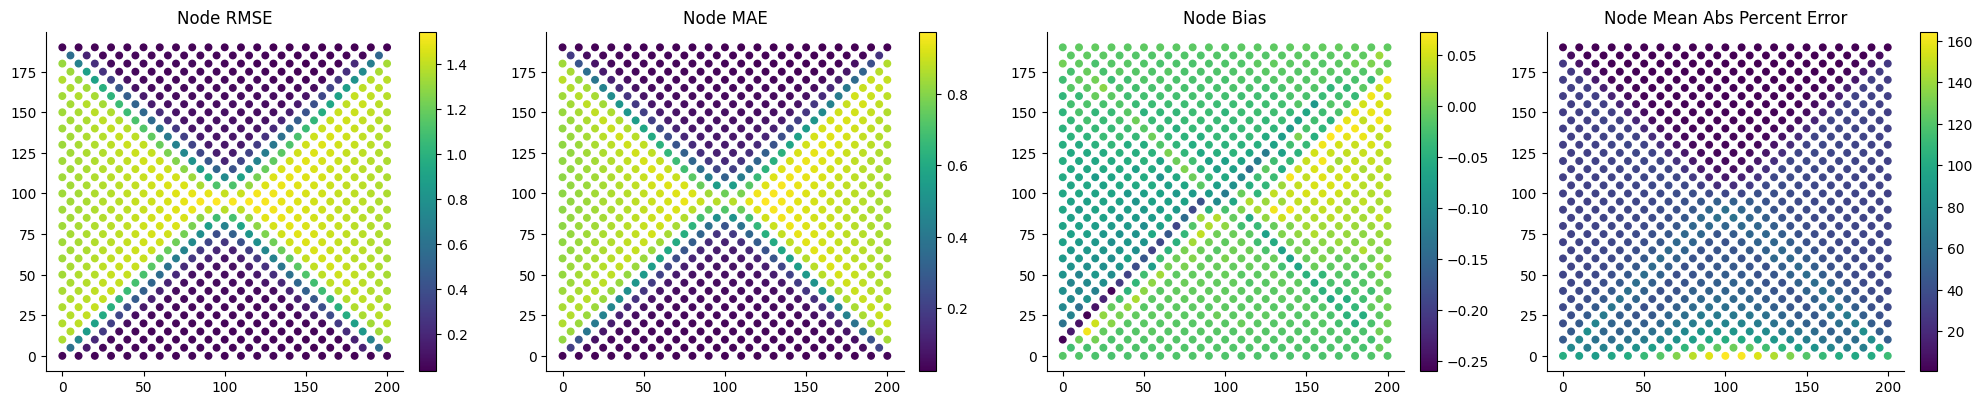

In [12]:
NODE_METRIC = "rmse"
NODE_TABLE_TOP_N = 20
NODE_PLOT_COLUMNS = ["rmse", "mae", "bias", "mean_abs_percent_error"]
NODE_POINT_SIZE = 22


display_field_node_error_summary(
    active_diag,
    metric=NODE_METRIC,
    top_n=NODE_TABLE_TOP_N,
    plot_columns=NODE_PLOT_COLUMNS,
    point_size=NODE_POINT_SIZE,
)


## 11. Interactive Field Viewer

In [13]:
FIELD_SAMPLE_MODE = "selected"
FIELD_SELECTED_SAMPLES = 0
FIELD_VIEW_FRAME = 10
FIELD_VIEW_COMPONENT = "U2"
FIELD_RANKING_METRIC = "rmse"
FIELD_PLOT_STYLE = "continuous"
FIELD_RANDOM_COUNT = 5


field_sample_viewer(
    active_diag,
    sample_mode=FIELD_SAMPLE_MODE,
    selected_samples=FIELD_SELECTED_SAMPLES,
    frame=FIELD_VIEW_FRAME,
    component=FIELD_VIEW_COMPONENT,
    ranking_metric=FIELD_RANKING_METRIC,
    plot_style=FIELD_PLOT_STYLE,
    random_count=FIELD_RANDOM_COUNT,
)


Output()

(VBox(children=(HBox(children=(ToggleButtons(description='Samples', options=('selected', 'best', 'worst', 'random'), value='selected'), Text(value='0', description='Selected', layout=Layout(width='260px'), placeholder='0 or 0, 4, 12'), BoundedIntText(value=5, description='Random n', layout=Layout(width='150px'), max=20, min=5), Button(button_style='primary', description='Refresh', layout=Layout(margin='0 0 0 16px', width='80px'), style=ButtonStyle()))), HBox(children=(HBox(children=(Label(value='Frame', layout=Layout(width='44px')), Button(description='-', layout=Layout(margin='0 2px 0 0', width='30px'), style=ButtonStyle()), IntSlider(value=10, continuous_update=False, layout=Layout(width='190px'), max=20, min=1), Button(description='+', layout=Layout(margin='0 0 0 2px', width='30px'), style=ButtonStyle())), layout=Layout(align_items='center', margin='0 14px 0 0')), Dropdown(description='Component', index=1, layout=Layout(width='185px'), options=(('U1', 0), ('U2', 1)), style=Descripti

## 12. Selected Sample Frame Evolution

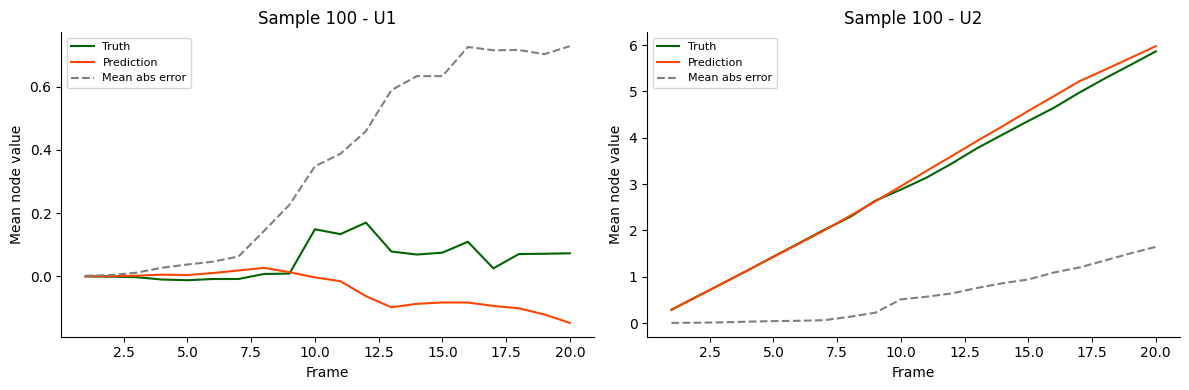

(<Figure size 1200x400 with 2 Axes>,
 array([[<Axes: title={'center': 'Sample 100 - U1'}, xlabel='Frame', ylabel='Mean node value'>,
         <Axes: title={'center': 'Sample 100 - U2'}, xlabel='Frame', ylabel='Mean node value'>]],
       dtype=object))

In [14]:
FRAME_EVOLUTION_SAMPLE = 100


plot_field_sample_frame_evolution(active_diag, sample=FRAME_EVOLUTION_SAMPLE)


## 13. Training Loss History

In [15]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


No loss_history.csv was found for this run.


(None, None)